In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from functools import partial

import haiku as hk # DeepMind's neural network library
import optax # Gradient-based optimization in JAX

from probjax.utils.odeint import odeint
from probjax.nn.transformers import Transformer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss
from probjax.distributions.sde import VPSDE, VESDE
from probjax.distributions import Empirical, Independent

from scoresbibm.src.utils.plot import use_style

from sbi.analysis import pairplot
import numpy as np

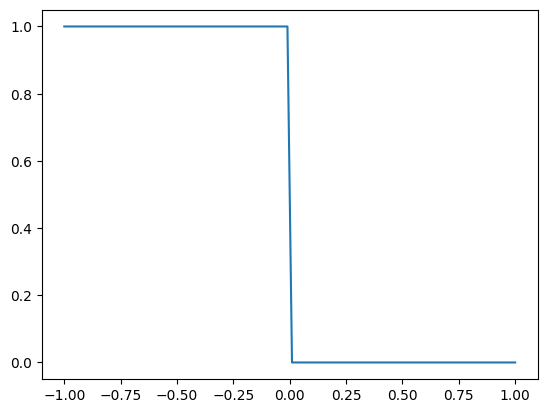

In [100]:
t = jnp.linspace(-1, 1, 100)

plt.plot(t, jax.nn.sigmoid(-1000*t))

In [2]:
from sbi.utils import posterior_nn
import torch
num_params = 0
for param in posterior_nn("nsf", hidden_features=100)(torch.ones((1000, 10)), torch.ones(1000,10)).parameters():
    num_params += param.flatten().shape[0]
num_params

294775

In [3]:
from scoresbibm.src.tasks import LinearGaussian, MixtureGaussian, TwoMoons, SLCP, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask

In [4]:
task1 = LinearGaussian(backend="jax")
task2 = MixtureGaussian(backend="jax")
task3 = TwoMoons(backend="jax")
task4 = SLCP(backend="jax")
task5 = NonlinearGaussianTreeAllConditionalTask(backend="jax")
task6 = NonlinearMarcovChainAllConditionalTask(backend="jax")

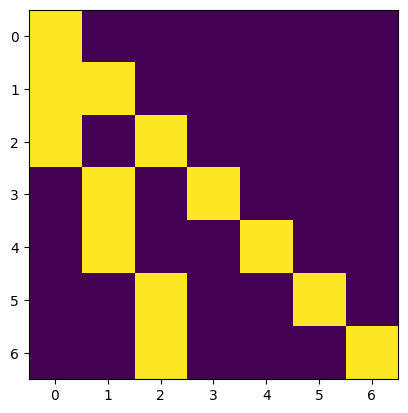

In [5]:
plt.imshow(task5.get_base_mask_fn()(task5.get_node_id(), None))

In [6]:
gaussian_linear_mask = task1.get_base_mask_fn()(task1.get_node_id(), None)
slcp_mask = task4.get_base_mask_fn()(task4.get_node_id(), None)
tree_mask = task5.get_base_mask_fn()(task5.get_node_id(), None)
hmm_mask = task6.get_base_mask_fn()(task6.get_node_id(), None)

In [66]:
from scoresbibm.src.utils.edge_masks import get_edge_mask_fn


edge_mask_fn_slcp = get_edge_mask_fn("min_faithfull",task6)

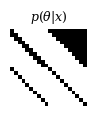

In [95]:
with use_style("pyloric"):
    fig  = plt.figure(figsize=(1,1))
    plt.imshow(edge_mask_fn_slcp(task6.get_node_id(), jnp.array([0]*10+ [1]*10, dtype=bool)), cmap="gray_r")
    plt.axis("off")
    plt.title(r"$p(\theta|x)$")
    plt.savefig("directed_posterior_mask_hmm.svg", bbox_inches="tight")

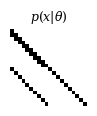

In [94]:
with use_style("pyloric"):
    fig  = plt.figure(figsize=(1,1))
    plt.imshow(edge_mask_fn_slcp(task6.get_node_id(), jnp.array([1]*10+ [0]*10, dtype=bool)), cmap="gray_r")
    plt.axis("off")
    plt.title(r"$p(x|\theta)$")
    plt.savefig("directed_likelihood_mask_hmm.svg", bbox_inches="tight")

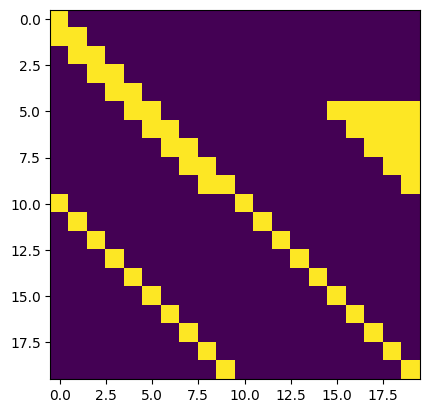

In [84]:
plt.imshow(edge_mask_fn_slcp(task6.get_node_id(), jnp.array([1]*5 + [0]*5+ [0]*5+ [1]*5, dtype=bool)))

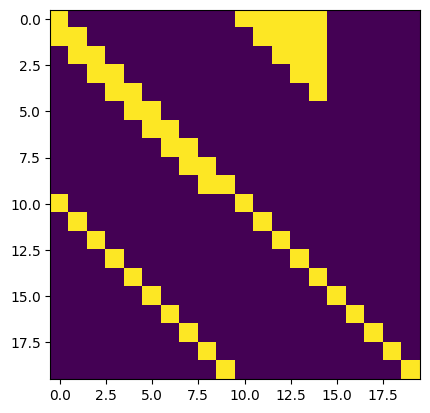

In [81]:
plt.imshow(edge_mask_fn_slcp(task6.get_node_id(), jnp.array([0]*10+ [1]*5+ [0]*5, dtype=bool)))

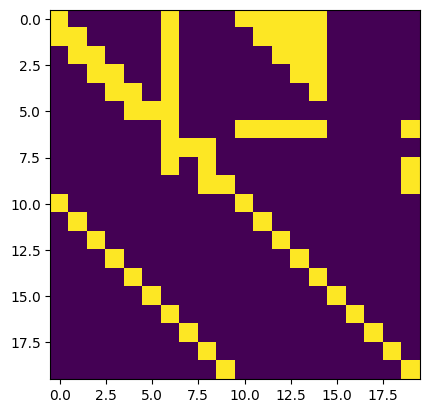

In [83]:
plt.imshow(edge_mask_fn_slcp(task6.get_node_id(), jnp.array([0]*10+ [1]*5+ [0]*3 +[0,1], dtype=bool)))

In [7]:
jnp.linalg.det(gaussian_linear_mask + gaussian_linear_mask.T)

Array(0., dtype=float32)

In [9]:
# Arrays will always land on the device first in the list.
# Device handling is automatic, depending for which device the function is compiled or where the data is placed.
jax.devices()

[cuda(id=0)]

In [10]:
# Set random key
key = jax.random.PRNGKey(0)

In [11]:
def connected_by_path_of_length_n(edge_mask, n):
    for _ in range(n):
        edge_mask = jnp.matmul(edge_mask, edge_mask)
    
    return edge_mask > 0

In [12]:
markovian = jnp.eye(100) + jnp.eye(100, k=-1)
parameter_iid = jnp.block([[jnp.eye(100), jnp.zeros((100, 100))], [jnp.eye(100), markovian]])

In [13]:
with jax.default_device(jax.devices("cpu")[0]):
    print(jnp.linalg.eigvalsh(parameter_iid))

[-0.207 -0.205 -0.203 -0.201 -0.197 -0.192 -0.187 -0.181 -0.174 -0.166
 -0.158 -0.149 -0.139 -0.128 -0.117 -0.105 -0.092 -0.079 -0.065 -0.051
 -0.036 -0.02  -0.004  0.013  0.03   0.047  0.065  0.083  0.102  0.12
  0.139  0.159  0.178  0.197  0.217  0.237  0.256  0.276  0.295  0.314
  0.334  0.353  0.371  0.39   0.408  0.425  0.443  0.46   0.476  0.492
  0.508  0.523  0.537  0.551  0.565  0.578  0.59   0.602  0.614  0.625
  0.635  0.645  0.655  0.664  0.673  0.681  0.688  0.696  0.703  0.709
  0.716  0.722  0.727  0.733  0.738  0.742  0.747  0.751  0.755  0.759
  0.762  0.765  0.768  0.771  0.774  0.776  0.778  0.78   0.782  0.784
  0.786  0.787  0.788  0.789  0.79   0.791  0.792  0.792  0.793  0.793
  1.207  1.207  1.208  1.208  1.209  1.21   1.211  1.212  1.213  1.214
  1.216  1.218  1.22   1.222  1.224  1.226  1.229  1.232  1.235  1.238
  1.241  1.245  1.249  1.253  1.258  1.262  1.267  1.273  1.278  1.284
  1.291  1.297  1.304  1.312  1.319  1.327  1.336  1.345  1.355  1.365
  1.375

In [14]:
parameter_iid_undirected = parameter_iid + parameter_iid.T

In [15]:
connected_by_path_of_length_n(parameter_iid_undirected, 9)

Array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], dtype=bool)

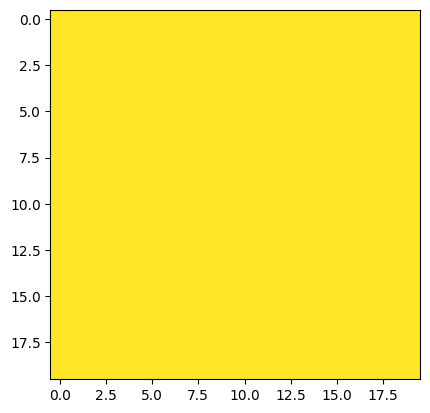

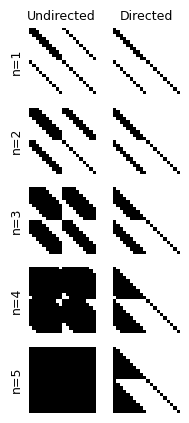

In [80]:
with use_style("pyloric"):
    fig, axes = plt.subplots(5, 2, figsize=(2,5))
    axes[0,0].imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 0), vmin=0., vmax=1., cmap="Greys")

    axes[1,0].imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 1), vmin=0., vmax=1., cmap="Greys")

    axes[2,0].imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 2), vmin=0., vmax=1., cmap="Greys")

    axes[3,0].imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 3), vmin=0., vmax=1., cmap="Greys")

    axes[4,0].imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 4), vmin=0., vmax=1., cmap="Greys")


    axes[0,1].imshow(connected_by_path_of_length_n(hmm_mask, 0), vmin=0., vmax=1., cmap="Greys")

    axes[1,1].imshow(connected_by_path_of_length_n(hmm_mask, 1), vmin=0., vmax=1., cmap="Greys")

    axes[2,1].imshow(connected_by_path_of_length_n(hmm_mask, 2), vmin=0., vmax=1., cmap="Greys")

    axes[3,1].imshow(connected_by_path_of_length_n(hmm_mask, 3), vmin=0., vmax=1., cmap="Greys")

    axes[4,1].imshow(connected_by_path_of_length_n(hmm_mask, 4), vmin=0., vmax=1., cmap="Greys")
    
    for i in range(5):
        for j in range(2):
            axes[i,j].spines['left'].set_visible(False)
            axes[i,j].spines['bottom'].set_visible(False)
            axes[i,j].set_xticks([])
            axes[i,j].set_yticks([])
    
    
    axes[0,0].set_title("Undirected")
    axes[0,1].set_title("Directed")
    # Enable y-labels
    axes[0,0].set_ylabel("n=1")
    axes[1,0].set_ylabel("n=2")
    axes[2,0].set_ylabel("n=3")
    axes[3,0].set_ylabel("n=4")
    axes[4,0].set_ylabel("n=5")
    fig.savefig("hmm_mask_per_layer")
    

(-0.5, 12.5, 12.5, -0.5)

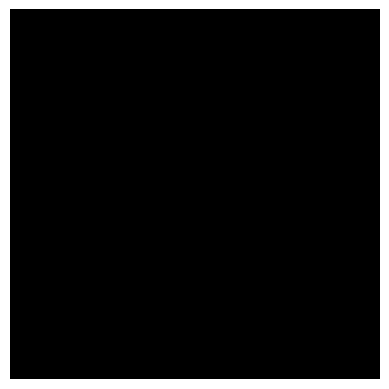

In [32]:
plt.imshow(connected_by_path_of_length_n(slcp_mask + slcp_mask.T, 1), vmin=0., vmax=1., cmap="gray_r")
plt.axis("off")

(-0.5, 12.5, 12.5, -0.5)

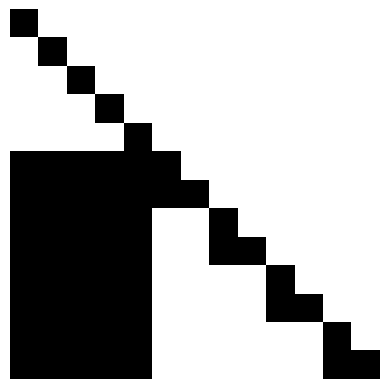

In [26]:
plt.imshow(connected_by_path_of_length_n(slcp_mask, 50), vmin=0., vmax=1., cmap="gray_r")
plt.axis("off")

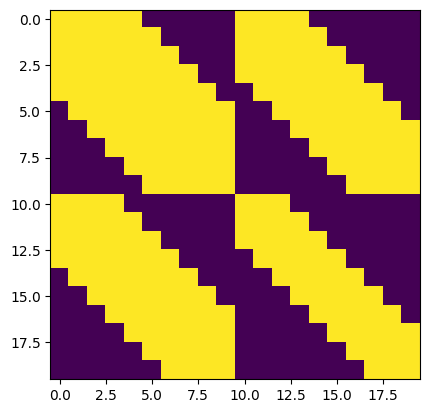

In [227]:
plt.imshow(connected_by_path_of_length_n(hmm_mask + hmm_mask.T, 2))